# Notebook 3.5 — Stage-1 Confirmation Run
### Detectability-Aware Post-Merger GW Anomaly Screening

This notebook repeats the Stage-1 comparison from Notebook 3 with a larger sample per grid cell and a few
additional diagnostics. The goal is to check whether the separation between graph-spectral statistics and
the total-power baseline is stable enough to carry forward.

The confirmation run uses:

- `N_PER_CELL=125` on a focused `(SNR, tau)` grid;
- category-wise and fixed-SNR power/eigenvalue correlations;
- a shuffle test that preserves CQT tile values while randomizing their positions.

`alpha=0.01` is used for the null threshold. Normalization and null calibration use `calib_block`; the
injection sweep uses `train_block`; `test_block` is not used.

`raw_lambda1` is the leading eigenvalue of the local graph built from the raw CQT map. `norm_lambda1`
uses the empirically normalized map from Notebook 3. `total_power_raw` is the excess-power baseline.

The shuffle test is interpreted as a test of sensitivity to the arrangement of time-frequency excess.
It does not by itself identify physical coherence or a particular post-merger ridge morphology.

**Depends on:** `nb1_artifacts/` from Notebook 1. Core functions are defined locally using the same
settings as Notebook 3.


In [ ]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa


## 1. Setup

Load Notebook 1 artifacts and define the same whitening, injection, CQT, and graph machinery used in
Notebook 3.


In [ ]:
# ---------------------------------------------------------------------------
# 1. Imports, config, Notebook 1 artifacts, and shared core functions
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import scipy.sparse.csgraph
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import spearmanr, wilcoxon
import librosa
from google.colab import drive; drive.mount('/content/drive')

SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb3_5_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found; run Notebook 1 first."

FS = 16384
WINDOW_DUR = 0.1
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)
F_LOW = 20.0
F_HIGH = 6000.0
EDGE_TRIM_S = 4.0
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))

BLOCKS = json.load(open(os.path.join(NB1_DIR, "gps_blocks.json")))
_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)
_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    assert np.all(np.isfinite(data))
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out))
    return out

def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0
    return h_t * (target_snr / base)

raw_noise_pools = {}
for name in ['calib_block', 'train_block', 'test_block']:
    arr = np.load(os.path.join(NB1_DIR, f"raw_{name}_L1.npy"))
    assert np.all(np.isfinite(arr))
    raw_noise_pools[name] = arr
    print(f"{name:12s}: loaded {len(arr)} samples ({len(arr)/FS:.0f}s)")

def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)
    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled
    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx

# Band-restricted CQT settings shared with Notebook 3.
CQT_FMIN = 500.0
CQT_N_BINS = 48
CQT_BINS_PER_OCTAVE = 12
CQT_HOP_LENGTH = 8
CQT_BAND_LOW = 1500.0
CQT_BAND_HIGH = 4000.0

_cqt_all_freqs = librosa.cqt_frequencies(n_bins=CQT_N_BINS, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE)
_cqt_band_mask = (_cqt_all_freqs >= CQT_BAND_LOW) & (_cqt_all_freqs <= CQT_BAND_HIGH)
cqt_band_freqs = _cqt_all_freqs[_cqt_band_mask]

def compute_cqt_banded(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH,
                        band_mask=_cqt_band_mask):
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)[band_mask, :]

print(f"\nCQT band mask: {_cqt_band_mask.sum()} bins in [{CQT_BAND_LOW}, {CQT_BAND_HIGH}] Hz")


Mounted at /content/drive
calib_block : loaded 16777216 samples (1024s)
train_block : loaded 16777216 samples (1024s)
test_block  : loaded 16777216 samples (1024s)

CQT band mask: 17 bins in [1500.0, 4000.0] Hz


## 2. Empirical CQT normalization

Rebuild the `calib_block` normalization used by Notebook 3 with the same seed and call order.


In [ ]:
# ---------------------------------------------------------------------------
# 2. Empirical CQT normalization
# ---------------------------------------------------------------------------
N_NORM_SAMPLES = 500

_norm_stack = []
for i in range(N_NORM_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    mag = compute_cqt_banded(w)
    _norm_stack.append(np.log1p(mag))
_norm_stack = np.stack(_norm_stack, axis=0)

cqt_bin_median = np.median(_norm_stack, axis=0)
cqt_bin_mad = np.median(np.abs(_norm_stack - cqt_bin_median[None, :, :]), axis=0)
cqt_bin_mad_safe = np.maximum(1.4826 * cqt_bin_mad, 1e-6)
del _norm_stack

def normalize_cqt(mag):
    z = (np.log1p(mag) - cqt_bin_median) / cqt_bin_mad_safe
    return np.maximum(z, 0.0)

print(f"Normalization: {N_NORM_SAMPLES} calib_block windows, shape {cqt_bin_median.shape}")


Normalization: 500 calib_block windows, shape (17, 205)


## 3. Graph statistics

For each window, compute the total CQT power together with the raw and normalized leading graph
eigenvalues.


In [ ]:
# ---------------------------------------------------------------------------
# 3. Graph construction and statistics
# ---------------------------------------------------------------------------
GRAPH_FREQ_RADIUS = 2
GRAPH_TIME_RADIUS = 2

def build_tf_graph(tf_map, freq_radius=GRAPH_FREQ_RADIUS, time_radius=GRAPH_TIME_RADIUS):
    n_freq, n_time = tf_map.shape
    n = n_freq * n_time
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols, data = [], [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            w = (tf_map[f_src, t_src] * tf_map[f_dst, t_dst]).reshape(-1)
            rows.append(src_idx); cols.append(dst_idx); data.append(w)
    rows = np.concatenate(rows); cols = np.concatenate(cols); data = np.concatenate(data)
    return scipy.sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

def leading_eigenvalue(A):
    if A.nnz == 0:
        return 0.0
    try:
        val = scipy.sparse.linalg.eigsh(A, k=1, which='LA', return_eigenvectors=False)
        return float(val[0])
    except Exception:
        return float(np.linalg.eigvalsh(A.toarray())[-1])

def compute_window_statistics(window):
    mag = compute_cqt_banded(window)
    z_pos = normalize_cqt(mag)
    A_raw = build_tf_graph(mag)
    A_norm = build_tf_graph(z_pos)
    return {
        'total_power_raw': float(mag.sum()),
        'total_power_norm': float(z_pos.sum()),
        'raw_lambda1': leading_eigenvalue(A_raw),
        'norm_lambda1': leading_eigenvalue(A_norm),
    }

HEADLINE_STATS = ['total_power_raw', 'raw_lambda1', 'norm_lambda1']


## 4. Null calibration

Calibrate the `alpha=0.01` threshold for the three headline statistics using `calib_block` noise-only
windows.


In [ ]:
# ---------------------------------------------------------------------------
# 4. Null calibration
# ---------------------------------------------------------------------------
N_CALIBRATION = 1500
ALPHA = 0.01

null_stats = {name: np.empty(N_CALIBRATION) for name in HEADLINE_STATS}
for i in range(N_CALIBRATION):
    w, _ = make_noise_only_window('calib_block')
    s = compute_window_statistics(w)
    for name in HEADLINE_STATS:
        null_stats[name][i] = s[name]
    if (i + 1) % 500 == 0:
        print(f"  calibrated {i+1}/{N_CALIBRATION}...")

thresholds = {name: np.percentile(null_stats[name], 100 * (1 - ALPHA)) for name in HEADLINE_STATS}
n_expected = ALPHA * N_CALIBRATION
print(f"\nalpha={ALPHA}: ~{n_expected:.0f} expected exceedances in the calibration sample")
for name in HEADLINE_STATS:
    print(f"  {name:18s}: threshold={thresholds[name]:.4f}")


  calibrated 500/1500...
  calibrated 1000/1500...
  calibrated 1500/1500...

alpha=0.01: ~15 expected exceedances in the calibration sample
  total_power_raw   : threshold=349952.3590
  raw_lambda1       : threshold=1076511.2152
  norm_lambda1      : threshold=55.3108


## 5. Larger confirmation sweep

Run a focused grid with `tau = [1, 3, 5, 10, 20, 40]` ms, `SNR = [4, 6, 8, 10, 12, 15]`, and
`N_PER_CELL=125`. The sweep uses `train_block` only and saves the per-window statistics.


In [ ]:
# ---------------------------------------------------------------------------
# 5. Confirmation sweep on train_block
# ---------------------------------------------------------------------------
TAU_GRID_MS = [1, 3, 5, 10, 20, 40]
SNR_GRID = [4, 6, 8, 10, 12, 15]
N_PER_CELL = 125

n_tau, n_snr = len(TAU_GRID_MS), len(SNR_GRID)
stats_grid = {name: np.empty((n_tau, n_snr, N_PER_CELL)) for name in HEADLINE_STATS}
fpeak_grid = np.empty((n_tau, n_snr, N_PER_CELL))

for i, tau_ms in enumerate(TAU_GRID_MS):
    for j, snr in enumerate(SNR_GRID):
        for k in range(N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('train_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=float(snr))
            s = compute_window_statistics(w)
            for name in HEADLINE_STATS:
                stats_grid[name][i, j, k] = s[name]
            fpeak_grid[i, j, k] = f_peak
    print(f"  tau={tau_ms:3d}ms done")

for name in HEADLINE_STATS:
    assert np.all(np.isfinite(stats_grid[name]))

np.savez(os.path.join(OUT_DIR, 'confirmation_sweep_full_stats.npz'),
         tau_grid_ms=np.array(TAU_GRID_MS), snr_grid=np.array(SNR_GRID),
         fpeak_grid=fpeak_grid, **{f'stats_{name}': stats_grid[name] for name in HEADLINE_STATS})
print(f"\nSaved {os.path.join(OUT_DIR, 'confirmation_sweep_full_stats.npz')}")


  tau=  1ms done
  tau=  3ms done
  tau=  5ms done
  tau= 10ms done
  tau= 20ms done
  tau= 40ms done

Saved /content/drive/MyDrive/gw_postmerger/nb3_5_artifacts/confirmation_sweep_full_stats.npz


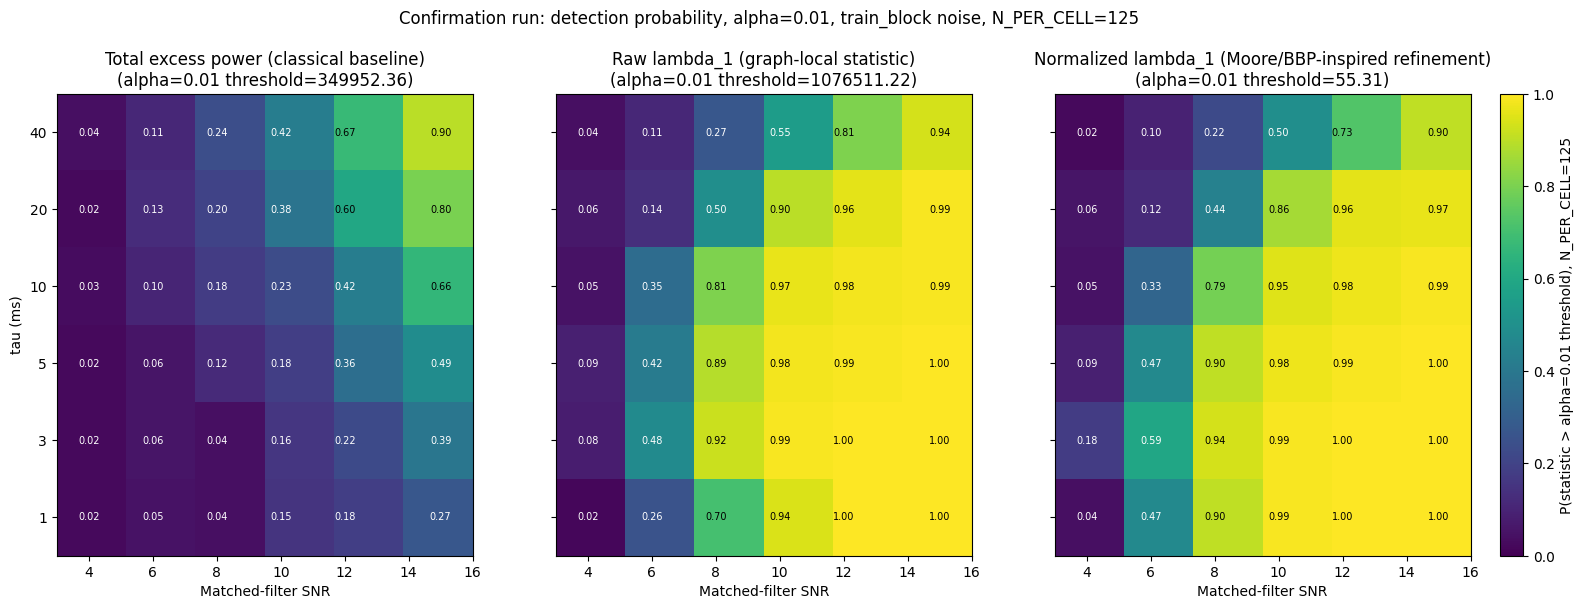

First grid SNR with P_det >= 0.9 for tau=1ms:
  total_power_raw   : not reached within grid (max SNR=15)
  raw_lambda1       : 10
  norm_lambda1      : 8


In [ ]:
# ---------------------------------------------------------------------------
# Detection probability and phase diagram
# ---------------------------------------------------------------------------
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (0.0, 1.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

p_det = {name: np.zeros((n_tau, n_snr)) for name in HEADLINE_STATS}
for name in HEADLINE_STATS:
    thr = thresholds[name]
    for i in range(n_tau):
        for j in range(n_snr):
            k = int(np.sum(stats_grid[name][i, j, :] > thr))
            p_det[name][i, j] = k / N_PER_CELL

fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
titles = {'total_power_raw': 'Total excess power (classical baseline)',
          'raw_lambda1': 'Raw lambda_1 (graph-local statistic)',
          'norm_lambda1': 'Normalized lambda_1 (Moore/BBP-inspired refinement)'}
for ax, name in zip(axes, HEADLINE_STATS):
    im = ax.imshow(p_det[name], aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1,
                    extent=[min(SNR_GRID) - 1, max(SNR_GRID) + 1, -0.5, n_tau - 0.5])
    ax.set_yticks(range(n_tau)); ax.set_yticklabels([str(t) for t in TAU_GRID_MS])
    ax.set_xlabel('Matched-filter SNR')
    ax.set_title(f'{titles[name]}\n(alpha=0.01 threshold={thresholds[name]:.2f})')
    for i in range(n_tau):
        for j in range(n_snr):
            ax.text(SNR_GRID[j], i, f'{p_det[name][i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if p_det[name][i, j] < 0.6 else 'black')
axes[0].set_ylabel('tau (ms)')
fig.colorbar(im, ax=axes, label=f'P(statistic > alpha={ALPHA} threshold), N_PER_CELL={N_PER_CELL}',
             fraction=0.02, pad=0.02)
plt.suptitle(f'Confirmation run: detection probability, alpha=0.01, train_block noise, '
             f'N_PER_CELL={N_PER_CELL}', y=1.02)
plt.savefig(os.path.join(OUT_DIR, 'plot_confirmation_phase_diagram.pdf'), bbox_inches='tight')
plt.show()

# First grid SNR reaching P_det >= 0.9 for tau=1 ms.
print("First grid SNR with P_det >= 0.9 for tau=1ms:")
for name in HEADLINE_STATS:
    row = p_det[name][TAU_GRID_MS.index(1), :]
    hits = [SNR_GRID[j] for j in range(n_snr) if row[j] >= 0.9]
    print(f"  {name:18s}: {hits[0] if hits else 'not reached within grid (max SNR=' + str(max(SNR_GRID)) + ')'}")


## 6. Category-wise correlations

For each damping-time row, pool the SNR values and measure the Pearson and Spearman correlations between
total power and each graph statistic. A separate noise-only sample provides a reference.


In [ ]:
# ---------------------------------------------------------------------------
# 6. Category-wise correlations
# ---------------------------------------------------------------------------
N_NOISE_FOR_CORR = 200
noise_power, noise_raw_lam, noise_norm_lam = [], [], []
for _ in range(N_NOISE_FOR_CORR):
    w, _ = make_noise_only_window('calib_block')
    s = compute_window_statistics(w)
    noise_power.append(s['total_power_raw'])
    noise_raw_lam.append(s['raw_lambda1'])
    noise_norm_lam.append(s['norm_lambda1'])

print(f"{'category':12s} {'n':>5s}  {'Pearson(power,raw)':>19s} {'Spearman':>9s}  "
      f"{'Pearson(power,norm)':>20s} {'Spearman':>9s}")

category_results = {}
for i, tau_ms in enumerate(TAU_GRID_MS):
    power = stats_grid['total_power_raw'][i, :, :].flatten()
    raw_lam = stats_grid['raw_lambda1'][i, :, :].flatten()
    norm_lam = stats_grid['norm_lambda1'][i, :, :].flatten()
    pr_raw = np.corrcoef(power, raw_lam)[0, 1]
    sp_raw = spearmanr(power, raw_lam).correlation
    pr_norm = np.corrcoef(power, norm_lam)[0, 1]
    sp_norm = spearmanr(power, norm_lam).correlation
    category_results[f'tau={tau_ms}ms'] = dict(pearson_raw=pr_raw, spearman_raw=sp_raw,
                                                 pearson_norm=pr_norm, spearman_norm=sp_norm)
    print(f"{'tau='+str(tau_ms)+'ms':12s} {len(power):5d}  {pr_raw:19.3f} {sp_raw:9.3f}  "
          f"{pr_norm:20.3f} {sp_norm:9.3f}")

pr_raw_n = np.corrcoef(noise_power, noise_raw_lam)[0, 1]
sp_raw_n = spearmanr(noise_power, noise_raw_lam).correlation
pr_norm_n = np.corrcoef(noise_power, noise_norm_lam)[0, 1]
sp_norm_n = spearmanr(noise_power, noise_norm_lam).correlation
category_results['noise'] = dict(pearson_raw=pr_raw_n, spearman_raw=sp_raw_n,
                                  pearson_norm=pr_norm_n, spearman_norm=sp_norm_n)
print(f"{'noise':12s} {N_NOISE_FOR_CORR:5d}  {pr_raw_n:19.3f} {sp_raw_n:9.3f}  "
      f"{pr_norm_n:20.3f} {sp_norm_n:9.3f}")

with open(os.path.join(OUT_DIR, 'category_correlations.json'), 'w') as f:
    json.dump(category_results, f, indent=2)
print(f"\nSaved {os.path.join(OUT_DIR, 'category_correlations.json')}")


category         n   Pearson(power,raw)  Spearman   Pearson(power,norm)  Spearman
tau=1ms        750                0.450     0.466                 0.455     0.453
tau=3ms        750                0.501     0.526                 0.523     0.523
tau=5ms        750                0.555     0.569                 0.562     0.557
tau=10ms       750                0.651     0.649                 0.665     0.651
tau=20ms       750                0.708     0.701                 0.719     0.702
tau=40ms       750                0.740     0.726                 0.740     0.712
noise          200                0.275     0.299                 0.245     0.271

Saved /content/drive/MyDrive/gw_postmerger/nb3_5_artifacts/category_correlations.json


## 7. Fixed-SNR correlations

At SNR 8, 10, and 12, pool across damping times and recompute the power/eigenvalue correlations. This
reduces the contribution of between-SNR variation to the correlation.


In [ ]:
# ---------------------------------------------------------------------------
# 7. Fixed-SNR correlations
# ---------------------------------------------------------------------------
FIXED_SNRS = [8, 10, 12]
print(f"{'SNR':>5s} {'n':>5s}  {'Pearson(power,raw)':>19s} {'Spearman':>9s}  "
      f"{'Pearson(power,norm)':>20s} {'Spearman':>9s}")

fixed_snr_results = {}
for snr in FIXED_SNRS:
    j = SNR_GRID.index(snr)
    power = stats_grid['total_power_raw'][:, j, :].flatten()
    raw_lam = stats_grid['raw_lambda1'][:, j, :].flatten()
    norm_lam = stats_grid['norm_lambda1'][:, j, :].flatten()
    pr_raw = np.corrcoef(power, raw_lam)[0, 1]
    sp_raw = spearmanr(power, raw_lam).correlation
    pr_norm = np.corrcoef(power, norm_lam)[0, 1]
    sp_norm = spearmanr(power, norm_lam).correlation
    fixed_snr_results[f'SNR={snr}'] = dict(pearson_raw=pr_raw, spearman_raw=sp_raw,
                                            pearson_norm=pr_norm, spearman_norm=sp_norm)
    print(f"{snr:5d} {len(power):5d}  {pr_raw:19.3f} {sp_raw:9.3f}  {pr_norm:20.3f} {sp_norm:9.3f}")

with open(os.path.join(OUT_DIR, 'fixed_snr_correlations.json'), 'w') as f:
    json.dump(fixed_snr_results, f, indent=2)
print(f"\nSaved {os.path.join(OUT_DIR, 'fixed_snr_correlations.json')}")


  SNR     n   Pearson(power,raw)  Spearman   Pearson(power,norm)  Spearman
    8   750                0.079     0.100                 0.014     0.014
   10   750                0.011     0.000                -0.039    -0.045
   12   750               -0.045    -0.053                -0.099    -0.106

Saved /content/drive/MyDrive/gw_postmerger/nb3_5_artifacts/fixed_snr_correlations.json


## 8. Shuffle test

Randomly permute the CQT tile positions while preserving the tile values and therefore total power.
Compare the leading eigenvalue before and after shuffling for noise and several injected categories.

The useful comparison is the size of the shuffle effect in injections relative to the noise baseline.
A reduction after shuffling shows sensitivity to tile arrangement, but does not by itself identify the
physical origin of that structure.


noise     : raw_lambda1  orig=  736235.1  shuffled=  336459.2  drop= 54.3%  (Wilcoxon p=1.63e-11)
            norm_lambda1 orig=     37.33  shuffled=     13.46  drop= 63.9%  (Wilcoxon p=1.63e-11)
tau=1ms   : raw_lambda1  orig= 4683664.4  shuffled=  634136.2  drop= 86.5%  (Wilcoxon p=1.63e-11)
            norm_lambda1 orig=    172.26  shuffled=     22.46  drop= 87.0%  (Wilcoxon p=1.63e-11)
tau=10ms  : raw_lambda1  orig= 4296830.5  shuffled=  784392.3  drop= 81.7%  (Wilcoxon p=1.63e-11)
            norm_lambda1 orig=    140.05  shuffled=     24.82  drop= 82.3%  (Wilcoxon p=1.63e-11)
tau=40ms  : raw_lambda1  orig= 1956855.6  shuffled=  597547.9  drop= 69.5%  (Wilcoxon p=1.63e-11)
            norm_lambda1 orig=     82.69  shuffled=     24.47  drop= 70.4%  (Wilcoxon p=1.63e-11)


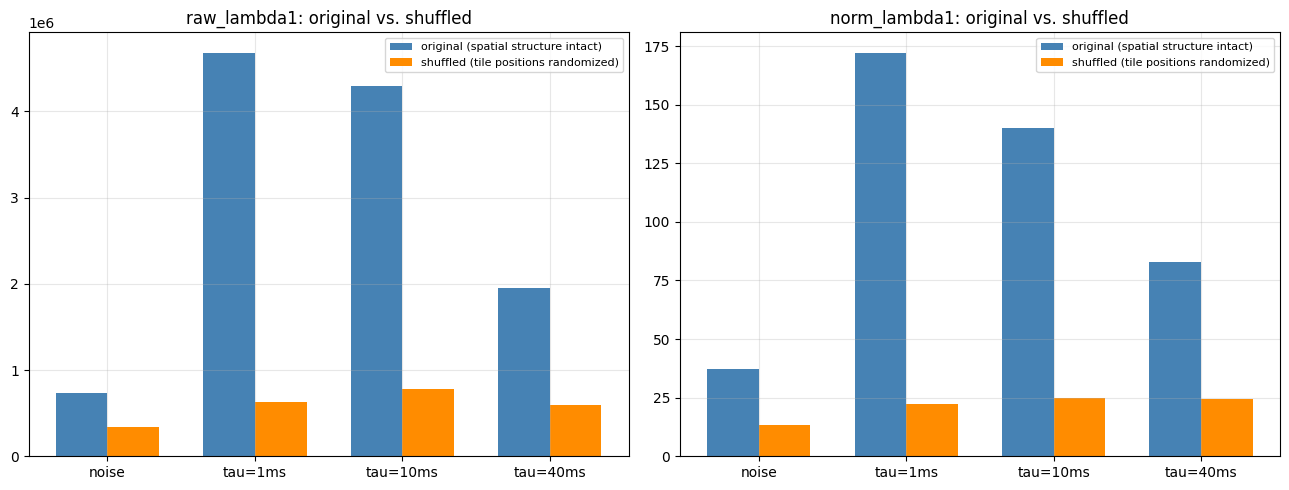


Saved /content/drive/MyDrive/gw_postmerger/nb3_5_artifacts/shuffle_test_results.json

Shuffle diagnostic:
Compare the percentage drop in each injected category with the noise baseline.
The shuffle preserves total CQT power by construction; changes in lambda_1 reflect sensitivity
to the arrangement of tile values rather than to their sum.


In [ ]:
# ---------------------------------------------------------------------------
# 8. Shuffle sanity test
# ---------------------------------------------------------------------------
SHUFFLE_SNR = 15.0
SHUFFLE_CATEGORIES = [None, 1, 10, 40]  # None denotes noise-only windows
N_SHUFFLE_PER_CATEGORY = 60

def shuffle_tf_map(tf_map, rng):
    flat = tf_map.reshape(-1).copy()
    rng.shuffle(flat)
    return flat.reshape(tf_map.shape)

shuffle_results = {}
for tau_ms in SHUFFLE_CATEGORIES:
    label = 'noise' if tau_ms is None else f'tau={tau_ms}ms'
    orig_raw, shuf_raw, orig_norm, shuf_norm, power_check = [], [], [], [], []
    for _ in range(N_SHUFFLE_PER_CATEGORY):
        if tau_ms is None:
            w, _ = make_noise_only_window('calib_block')
        else:
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('train_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=SHUFFLE_SNR)
        mag = compute_cqt_banded(w)
        z_pos = normalize_cqt(mag)

        A_raw_orig = build_tf_graph(mag)
        A_norm_orig = build_tf_graph(z_pos)
        lam_raw_orig = leading_eigenvalue(A_raw_orig)
        lam_norm_orig = leading_eigenvalue(A_norm_orig)

        mag_shuf = shuffle_tf_map(mag, rng)
        z_pos_shuf = shuffle_tf_map(z_pos, rng)
        lam_raw_shuf = leading_eigenvalue(build_tf_graph(mag_shuf))
        lam_norm_shuf = leading_eigenvalue(build_tf_graph(z_pos_shuf))

        power_check.append(np.isclose(mag.sum(), mag_shuf.sum()))
        orig_raw.append(lam_raw_orig); shuf_raw.append(lam_raw_shuf)
        orig_norm.append(lam_norm_orig); shuf_norm.append(lam_norm_shuf)

    orig_raw, shuf_raw = np.array(orig_raw), np.array(shuf_raw)
    orig_norm, shuf_norm = np.array(orig_norm), np.array(shuf_norm)
    assert all(power_check), "Shuffling changed total power."

    pct_drop_raw = 100 * (1 - shuf_raw.mean() / orig_raw.mean())
    pct_drop_norm = 100 * (1 - shuf_norm.mean() / orig_norm.mean())
    try:
        _, p_raw = wilcoxon(orig_raw, shuf_raw)
        _, p_norm = wilcoxon(orig_norm, shuf_norm)
    except ValueError:
        p_raw = p_norm = float('nan')  # Wilcoxon is undefined if all paired differences vanish

    shuffle_results[label] = dict(
        orig_raw_mean=float(orig_raw.mean()), shuf_raw_mean=float(shuf_raw.mean()),
        pct_drop_raw=float(pct_drop_raw), wilcoxon_p_raw=float(p_raw),
        orig_norm_mean=float(orig_norm.mean()), shuf_norm_mean=float(shuf_norm.mean()),
        pct_drop_norm=float(pct_drop_norm), wilcoxon_p_norm=float(p_norm),
    )
    print(f"{label:10s}: raw_lambda1  orig={orig_raw.mean():10.1f}  shuffled={shuf_raw.mean():10.1f}  "
          f"drop={pct_drop_raw:5.1f}%  (Wilcoxon p={p_raw:.2e})")
    print(f"{'':10s}  norm_lambda1 orig={orig_norm.mean():10.2f}  shuffled={shuf_norm.mean():10.2f}  "
          f"drop={pct_drop_norm:5.1f}%  (Wilcoxon p={p_norm:.2e})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['noise' if t is None else f'tau={t}ms' for t in SHUFFLE_CATEGORIES]
for ax, key_orig, key_shuf, title in [
        (axes[0], 'orig_raw_mean', 'shuf_raw_mean', 'raw_lambda1: original vs. shuffled'),
        (axes[1], 'orig_norm_mean', 'shuf_norm_mean', 'norm_lambda1: original vs. shuffled')]:
    x = np.arange(len(labels))
    orig_vals = [shuffle_results[l][key_orig] for l in labels]
    shuf_vals = [shuffle_results[l][key_shuf] for l in labels]
    width = 0.35
    ax.bar(x - width/2, orig_vals, width, label='original (spatial structure intact)', color='steelblue')
    ax.bar(x + width/2, shuf_vals, width, label='shuffled (tile positions randomized)', color='darkorange')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_shuffle_sanity_test.pdf'))
plt.show()

with open(os.path.join(OUT_DIR, 'shuffle_test_results.json'), 'w') as f:
    json.dump(shuffle_results, f, indent=2)
print(f"\nSaved {os.path.join(OUT_DIR, 'shuffle_test_results.json')}")

print("\nShuffle diagnostic:")
print("Compare the percentage drop in each injected category with the noise baseline.")
print("The shuffle preserves total CQT power by construction; changes in lambda_1 reflect sensitivity")
print("to the arrangement of tile values rather than to their sum.")


## 9. Summary

Section 5 reports the first grid SNR at which each statistic reaches `P_det >= 0.9` for `tau=1 ms`.
Sections 6 and 7 report power/eigenvalue correlations under different pooling choices, and Section 8
measures the effect of randomizing the time-frequency layout while holding total power fixed.

These checks are used to decide whether the Stage-1 graph statistic is sufficiently distinct from the
power baseline to carry into the next stage. The interpretation remains limited to organization of
time-frequency excess; this notebook does not establish a specific physical-coherence mechanism.

```text
nb3_5_artifacts/
  confirmation_sweep_full_stats.npz
  plot_confirmation_phase_diagram.pdf
  category_correlations.json
  fixed_snr_correlations.json
  shuffle_test_results.json
  plot_shuffle_sanity_test.pdf
```

**Next:** Notebook 4 applies the Stage-2 damping-time estimators.
